# Thresholds and clustering

The model scores pairs. It does not decide anything. This notebook turns scores
into a linked dataset: choose a threshold, understand what that choice costs,
group the surviving pairs into people, and export the result.

**What you will do**

1. Load the trained model saved in chapter 2.6 — without re-estimating anything
2. Read the score distribution
3. Test threshold sensitivity, and see why the choice is not statistical
4. Inspect a borderline pair to see what the model was reasoning about
5. Cluster pairs into entities and check the result against the 1:1 expectation
6. Export a linked dataset

## 0. Setup and loading the trained model

Estimation is expensive; scoring is cheap. A saved model is loaded by passing the
path to `settings` — nothing is re-estimated, and the numbers below are therefore
reproducible even though the *u* estimation that produced them was not seeded.

In [1]:
import unicodedata
from pathlib import Path

import pandas as pd

pd.set_option("display.max_columns", 25)
pd.set_option("display.width", 130)

DATA = Path("../../data")
if not DATA.exists():
    DATA = Path("data")

fonasa = pd.read_csv(DATA / "fonasa_sample.csv", dtype=str)
suseso = pd.read_csv(DATA / "suseso_sample.csv", dtype=str)


def basic_text_clean(series):
    return (series.astype("string").str.strip().str.upper()
            .str.replace(r"\s+", " ", regex=True))


def remove_accents(value):
    if pd.isna(value):
        return pd.NA
    value = unicodedata.normalize("NFKD", str(value))
    return "".join(c for c in value if not unicodedata.combining(c))


def standardise_name(series):
    cleaned = basic_text_clean(series)
    cleaned = cleaned.map(remove_accents, na_action="ignore").astype("string")
    cleaned = cleaned.str.replace(r"[^A-ZN ]", "", regex=True)
    return cleaned.str.replace(r"\s+", " ", regex=True).str.strip()


def clean_sex(series):
    cleaned = basic_text_clean(series)
    return cleaned.replace({"HOMBRE": "M", "MUJER": "F", "MASCULINO": "M",
                            "FEMENINO": "F", "": pd.NA})


for df in (fonasa, suseso):
    for col in ["nombre", "ap1", "ap2"]:
        df[f"{col}_clean"] = standardise_name(df[col])
    df["sexo_clean"] = clean_sex(df["sexo"])
    df["nac_clean"] = basic_text_clean(df["nacionalidad"])

CLEAN = ["nombre_clean", "ap1_clean", "ap2_clean", "sexo_clean", "nac_clean"]
TRUE_MATCHES = 4500

print(f"fonasa: {len(fonasa):,} records | suseso: {len(suseso):,} records")
print(f"true matches present in the data: {TRUE_MATCHES:,}")


import phonetics


def dmeta_primary(value):
    """Primary Double Metaphone code, as a string. Used for blocking."""
    if pd.isna(value) or value == "":
        return None
    try:
        return phonetics.dmetaphone(str(value))[0] or None
    except Exception:
        return None


def dmeta_list(value):
    """Both Double Metaphone codes, as a list. This is the form Splink's
    comparison functions expect for a `dmeta_col_name` argument."""
    if pd.isna(value) or value == "":
        return None
    try:
        return [c for c in phonetics.dmetaphone(str(value)) if c] or None
    except Exception:
        return None


for df in (fonasa, suseso):
    for col in ["nombre_clean", "ap1_clean", "ap2_clean"]:
        stem = col.replace("_clean", "")
        df[f"{stem}_dm"] = df[col].map(dmeta_primary)      # string, for blocking
        df[f"{stem}_dmeta"] = df[col].map(dmeta_list)      # list, for comparisons

MODEL_COLS = (["unique_id"] + CLEAN
              + ["nombre_dm", "ap1_dm", "ap2_dm"]
              + ["nombre_dmeta", "ap1_dmeta", "ap2_dmeta"])
fonasa_m = fonasa[MODEL_COLS + ["true_person_id"]].copy()
suseso_m = suseso[MODEL_COLS + ["true_person_id"]].copy()

print("phonetic example:  GONZALEZ ->",
      dmeta_primary("GONZALEZ"), "(blocking) /", dmeta_list("GONZALEZ"), "(comparison)")

fonasa: 30,000 records | suseso: 27,000 records
true matches present in the data: 4,500
phonetic example:  GONZALEZ -> KNSLS (blocking) / ['KNSLS'] (comparison)


In [2]:
from pathlib import Path
from splink import DuckDBAPI, Linker
import vl_convert as vlc
from IPython.display import Image


def show(chart, scale=2):
    return Image(vlc.vegalite_to_png(chart.to_json(), scale=scale))


MODEL_DIR = Path("../../models")
if not MODEL_DIR.exists():
    MODEL_DIR = Path("models")
model_path = MODEL_DIR / "linkage-model.json"

linker = Linker(
    input_table_or_tables=[fonasa_m, suseso_m],
    settings=str(model_path),          # a path to a saved model works directly
    db_api=DuckDBAPI(),
    input_table_aliases=["fonasa", "suseso"],
)
print(f"loaded trained model from {model_path}")

loaded trained model from ../../models/linkage-model.json


In [3]:
df_predict = linker.inference.predict()
predictions = df_predict.as_pandas_dataframe()
predictions["is_true_match"] = (
    predictions["true_person_id_l"] == predictions["true_person_id_r"]
)

TRUE_MATCHES = 4500
print(f"candidate pairs scored: {len(predictions):,}")

Blocking time: 0.06 seconds
Predict time: 0.09 seconds


candidate pairs scored: 8,868


## 1. The score distribution

Before choosing a threshold, look at what there is to threshold.

In [4]:
bands = pd.cut(
    predictions["match_probability"],
    bins=[-0.001, 0.001, 0.01, 0.1, 0.5, 0.9, 0.99, 1.0],
    labels=["<0.001", "0.001-0.01", "0.01-0.1", "0.1-0.5",
            "0.5-0.9", "0.9-0.99", ">0.99"],
)
dist = pd.DataFrame({
    "pairs": bands.value_counts().sort_index(),
    "of which true matches": predictions.groupby(bands, observed=False)["is_true_match"].sum(),
})
dist["share correct"] = (dist["of which true matches"] / dist["pairs"]).round(3)
dist

,pairs,of which true matches,share correct
match_probability,,,
<0.001,6612,214,0.032
0.001-0.01,393,85,0.216
0.01-0.1,289,108,0.374
0.1-0.5,180,103,0.572
0.5-0.9,127,110,0.866
0.9-0.99,78,73,0.936
>0.99,1189,1189,1.000


The distribution is strongly **bimodal**, which is what a working model looks
like: a large mass of pairs the model is confident are not matches, a smaller
mass it is confident are, and relatively few in between.

The `share correct` column is the useful one. In the top band nearly every pair
is right; in the bottom bands nearly none are. The middle bands are where the
threshold decision actually bites, and they hold only a small fraction of the
pairs.

A model whose distribution is *not* bimodal — a smooth spread across the range —
is telling you it cannot separate the two populations, and no threshold will
rescue it.

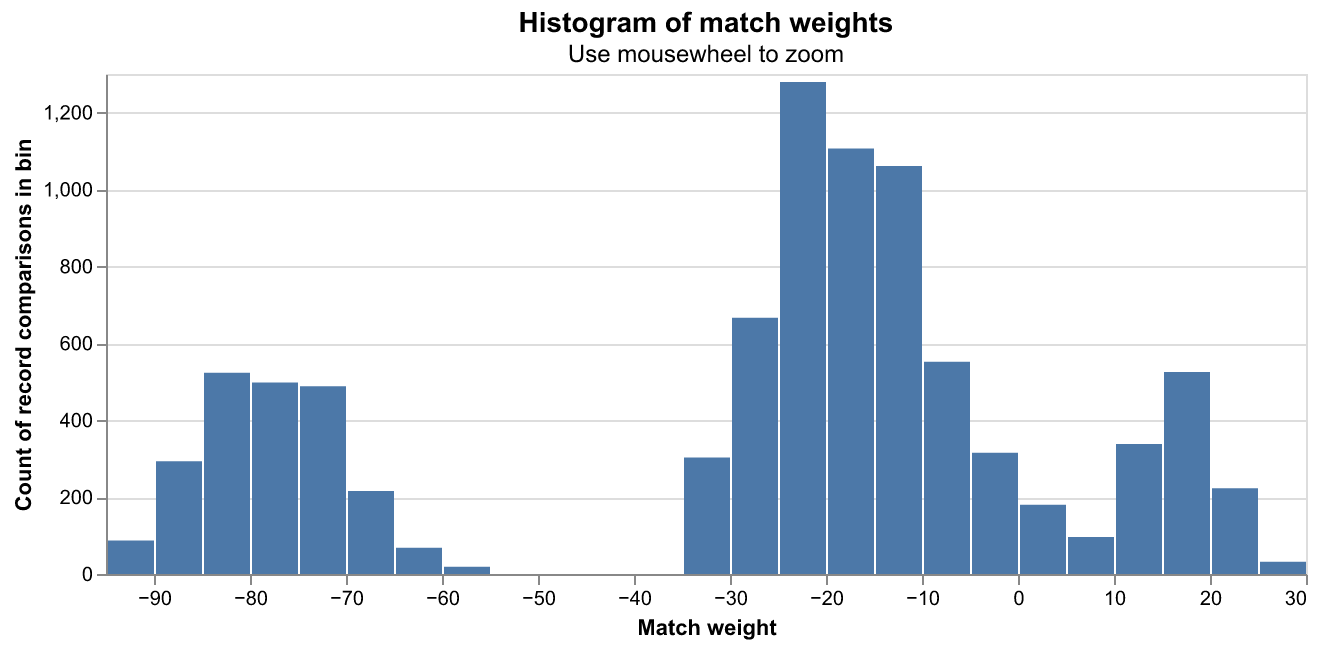

In [5]:
show(linker.visualisations.match_weights_histogram(df_predict))

## 2. Threshold sensitivity

Now sweep the threshold and measure the consequence at each setting.

In [6]:
rows = []
for t in [0.10, 0.30, 0.50, 0.70, 0.90, 0.95, 0.99, 0.999]:
    sel = predictions[predictions["match_probability"] >= t]
    tp = int(sel["is_true_match"].sum())
    fp = len(sel) - tp
    precision = tp / len(sel) if len(sel) else float("nan")
    recall = tp / TRUE_MATCHES
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0
    rows.append({"threshold": t, "pairs_accepted": len(sel),
                 "true_matches": tp, "false_matches": fp,
                 "precision": round(precision, 4), "recall": round(recall, 4),
                 "f1": round(f1, 4)})

sensitivity = pd.DataFrame(rows)
sensitivity

,threshold,pairs_accepted,true_matches,false_matches,precision,recall,f1
0,0.100,1574,1475,99,0.9371,0.3278,0.4857
1,0.300,1455,1411,44,0.9698,0.3136,0.4739
2,0.500,1394,1372,22,0.9842,0.3049,0.4656
3,0.700,1339,1326,13,0.9903,0.2947,0.4542
4,0.900,1267,1262,5,0.9961,0.2804,0.4377
5,0.950,1236,1236,0,1.0000,0.2747,0.4310
6,0.990,1189,1189,0,1.0000,0.2642,0.4180
7,0.999,1118,1118,0,1.0000,0.2484,0.3980


Read the `false_matches` column alongside `recall`. Moving the threshold from
0.99 down to 0.10 buys a few more true matches and admits a rather larger number
of wrong ones.

**Which row you want is not a statistical question.** It is the decision recorded
in chapter 2.1, about which error your use case can least afford:

- If a false match means a person wrongly denied or granted something, take a
  high threshold and accept the missed matches.
- If you are estimating coverage and will correct for error statistically, a
  lower threshold with a *measured* false-match rate may serve better.
- If the two errors genuinely cost the same, maximising F1 is defensible — and
  only then.

Whatever you choose, **report the threshold and its measured error rates
together**. A match count without a threshold is not a result.

## 3. What was the model thinking?

A threshold near the middle of the distribution will accept some pairs and reject
others that look similar. The waterfall chart decomposes an individual pair's
score into the contribution of each field, which is the tool for understanding —
and for explaining to a reviewer — why a specific pair scored as it did.

In [7]:
borderline = predictions[
    (predictions["match_probability"] > 0.3) & (predictions["match_probability"] < 0.9)
].sort_values("match_probability")

print(f"pairs in the borderline band: {len(borderline):,}")
print(f"of which are true matches   : {int(borderline['is_true_match'].sum()):,}")

cols = ["nombre_clean_l", "nombre_clean_r", "ap1_clean_l", "ap1_clean_r",
        "ap2_clean_l", "ap2_clean_r", "match_probability", "is_true_match"]
borderline[cols].head(8)

pairs in the borderline band: 188
of which are true matches   : 149


,nombre_clean_l,nombre_clean_r,ap1_clean_l,ap1_clean_r,ap2_clean_l,ap2_clean_r,match_probability,is_true_match
3781,LUIS LEONCIO,LUIS LEUNCIU,PULGAR,PULGAR,ORTEGA,ROTEG,0.303830,True
7859,GERAL B,GERAL BENJAMIN,VALENCIA,VALENCIA,GORMAS,GURMES,0.308447,True
7650,VIVIANADEL CARMEN,VIVIANA DEL CARMEN,RAMIREZ,RAMIREZ,SEGUVIE,SEGOVIA,0.317323,True
4074,LUCIE,LUCIA,LOBOS,LOBOS,OLIVA,SLOIVA,0.323012,True
7960,ALBERTINA DE LAS NIE,None,CISTERNAS,CISTERNES,ACUNA,ACUNA,0.330923,True
7227,ADRIANA DEL CARMEN,ADRIANA DEL C,GOMEZ,GOMEZ,SALAZAR,SELEZER,0.331052,True
8389,MAXIMILIANO ALEJANDR,None,VALENZUELA,VALENZUELA,FERNANDEZ,FERNANDEZ,0.332283,False
2353,LUCIANO SEBASTIAN,LUCINAO,ONATE,ONATE,PINCHULEF,PINCHULWF,0.334339,True


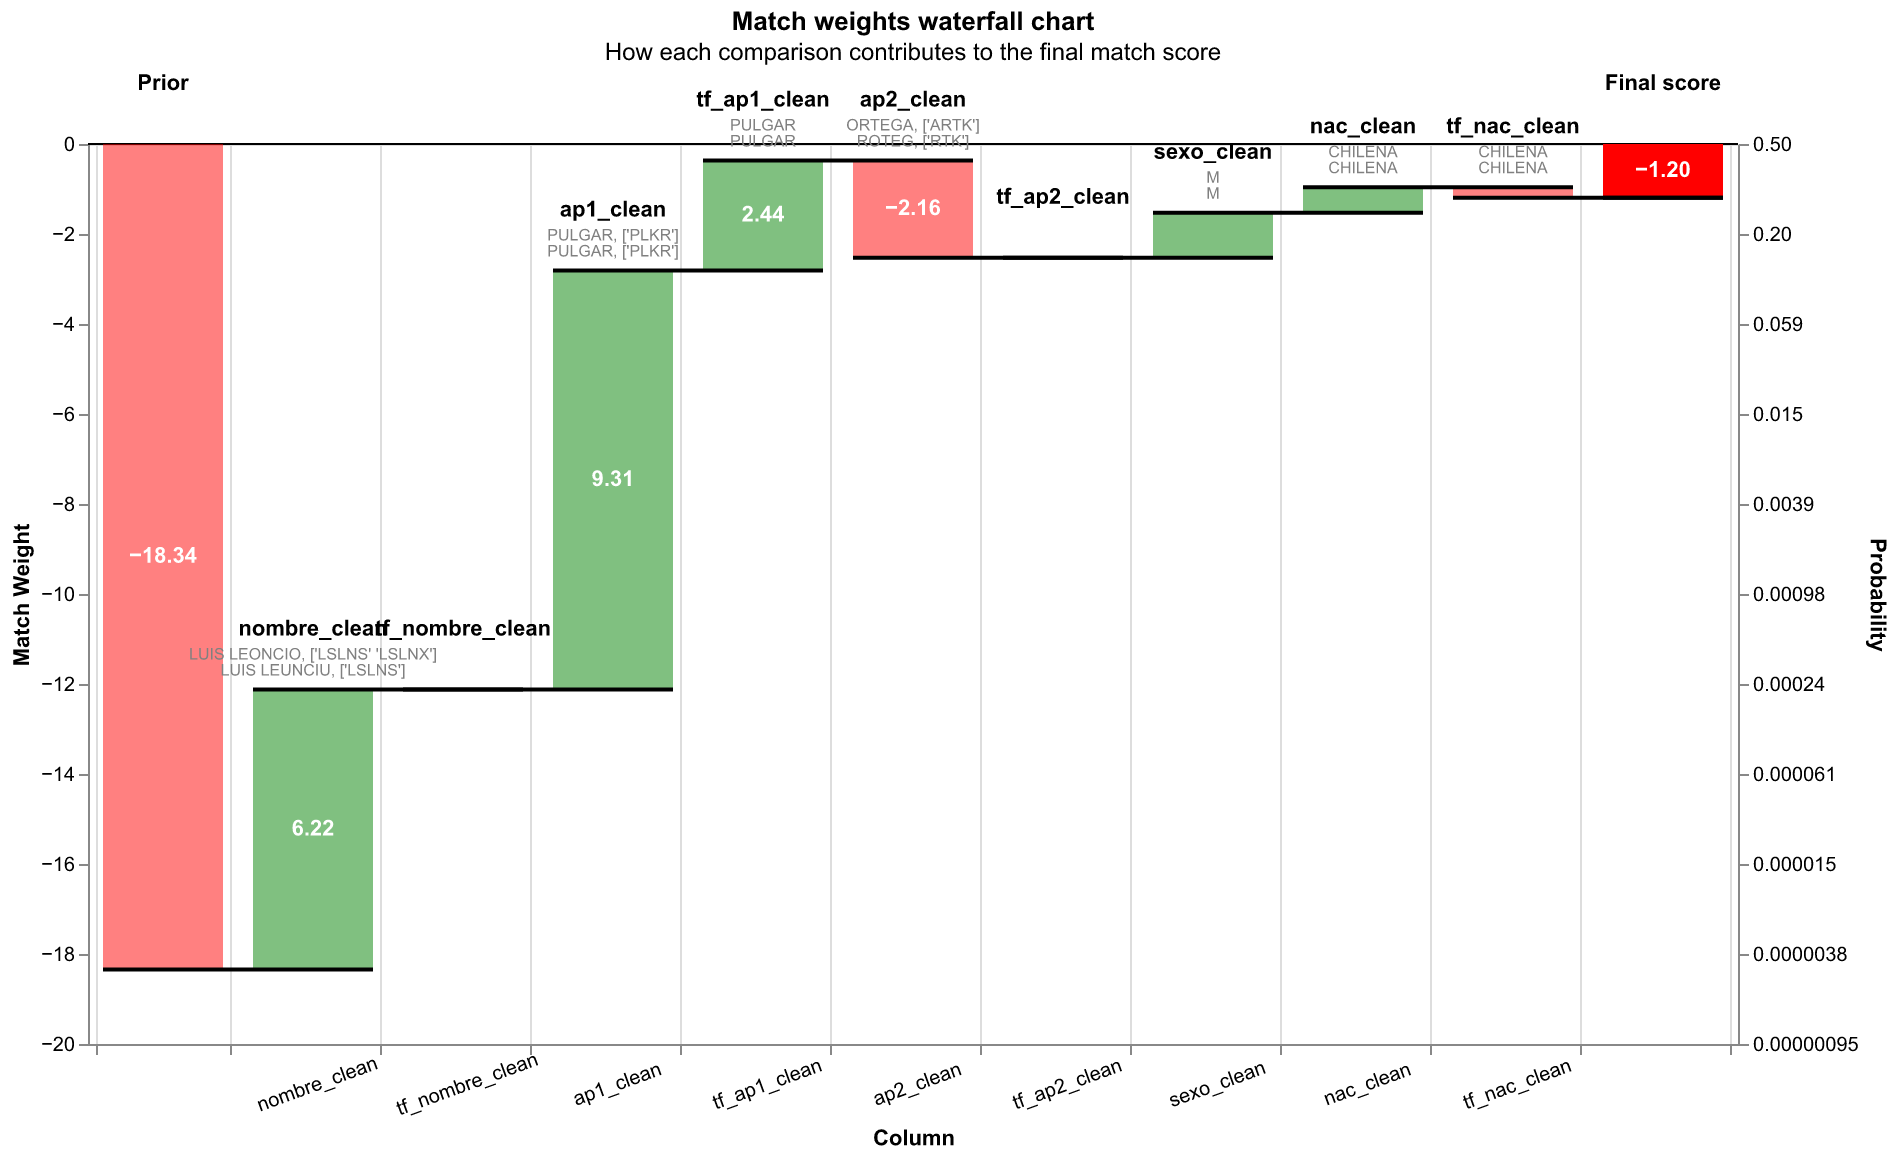

In [8]:
records = borderline.head(4).to_dict(orient="records")
show(linker.visualisations.waterfall_chart(records, filter_nulls=False))

Look at the pairs in the table above before reading the chart. They are worth
studying, because they are what "hard" actually looks like:

- `LUIS LEONCIO` / `LUIS LEUNCIU` — two vowels wrong in the given name, one in
  the surname
- `VIVIANADEL CARMEN` / `VIVIANA DEL CARMEN` — a missing space, which our
  cleaning did not fix because it removes extra spaces but cannot insert one
- `ALBERTINA DE LAS NIE` / *missing* — a truncated name on one side and no given
  name at all on the other

Of the 188 pairs in this borderline band, **149 are genuine matches**. The model
is not confused about a random selection of pairs; it is unsure about pairs that
a careful human would mostly accept. That is a strong argument for sending this
band to clerical review rather than letting the threshold decide it silently.

Each column of the chart is one pair. The bars show how each field moved the
score up or down from the prior, and the final bar is where it ended up.

This is the chart to use in clerical review: it turns "the model gave 0.62" into
"the surnames agreed strongly, the given name only loosely, and sex disagreed",
which a human reviewer can actually judge.

```{note}
`waterfall_chart()` requires `retain_intermediate_calculation_columns=True` in
the settings. Without it the call fails with a `ValueError` about missing
columns — a common first encounter with Splink, and the reason that argument was
set back in chapter 2.6.
```

## 4. From pairs to people

A threshold gives you accepted **pairs**. Most uses need **entities**: one row
per person, with the records that belong to them.

That is not just a matter of collecting pairs, because pairwise decisions can be
inconsistent. If A links to B and B links to C, but A does not link to C, are
those one person or two? Clustering resolves it: Splink builds a graph of
accepted pairs and takes connected components, so A, B and C become one cluster.

In [9]:
CLUSTER_THRESHOLD = 0.9

clusters = linker.clustering.cluster_pairwise_predictions_at_threshold(
    df_predict, threshold_match_probability=CLUSTER_THRESHOLD
)
clusters_df = clusters.as_pandas_dataframe()

print(f"records in clusters: {len(clusters_df):,}")
print(f"distinct clusters  : {clusters_df['cluster_id'].nunique():,}")

Completed iteration 1, num edges remaining to process: 0


records in clusters: 57,000
distinct clusters  : 55,733


In [10]:
sizes = clusters_df["cluster_id"].value_counts().value_counts().sort_index()
size_table = pd.DataFrame({"records in cluster": sizes.index, "number of clusters": sizes.values})
size_table["records covered"] = size_table["records in cluster"] * size_table["number of clusters"]
size_table

,records in cluster,number of clusters,records covered
0,1,54466,54466
1,2,1267,2534


Two things to read here.

Most clusters contain a **single** record: a person present in only one register,
or one whose match was never found. That is expected — the two registers overlap
in 4,500 people out of 57,000 records — but it does mean the count of clusters is
not a count of matched people.

Clusters of **two** are the successful links. Clusters **larger than two** should
not exist at all in a 1:1 link, and each one is a signal: either the threshold is
too permissive, or several genuinely different people are indistinguishable on
the available fields.

In [11]:
oversized = clusters_df["cluster_id"].value_counts()
oversized = oversized[oversized > 2]

print(f"clusters larger than 2 records: {len(oversized):,}")
if len(oversized):
    example = clusters_df[clusters_df["cluster_id"] == oversized.index[0]]
    print()
    print(example[["cluster_id", "unique_id", "nombre_clean", "ap1_clean",
                   "ap2_clean", "sexo_clean"]].to_string(index=False))

clusters larger than 2 records: 0


Here there are none: at a threshold of 0.9 every cluster holds either one record
or two, exactly as a 1:1 link should. That is a genuine quality signal, and it is
one you can obtain without any ground truth — which is what makes it valuable on
real data.

Whatever the count, **check it and report it**. A 1:1 linkage that produced
clusters of five has a problem no match rate will reveal.

Where oversized clusters do appear, the usual responses are to raise the
threshold, to add a field that separates the people involved, or to route those
clusters to clerical review rather than resolving them automatically.

## 5. The linked dataset

Finally, the deliverable: one row per accepted link, carrying the record
identifier from each side plus the score that produced it.

In [12]:
LINK_THRESHOLD = 0.9

linked = (
    predictions[predictions["match_probability"] >= LINK_THRESHOLD]
    [["unique_id_l", "unique_id_r", "match_probability", "match_weight"]]
    .rename(columns={"unique_id_l": "fonasa_record",
                     "unique_id_r": "suseso_record"})
    .sort_values("match_probability", ascending=False)
    .reset_index(drop=True)
)

print(f"linked pairs at threshold {LINK_THRESHOLD}: {len(linked):,}")
linked.head(5)

linked pairs at threshold 0.9: 1,267


,fonasa_record,suseso_record,match_probability,match_weight
0,F0016814,S0024943,1.0,28.833901
1,F0006737,S0007569,1.0,27.511973
2,F0008107,S0026370,1.0,27.248939
3,F0000357,S0015452,1.0,26.884235
4,F0020590,S0018104,1.0,26.884235


Note what this file does **not** contain: no names, no other identifying fields.
The linked output is a crosswalk between two record identifiers. Each institution
joins it back to its own records using the internal key from chapter 2.3, which
is the separation principle carried through to the deliverable.

Keep the `match_probability` column. It lets a downstream analyst apply a stricter
threshold without re-running the linkage, and it is what an uncertainty-aware
analysis needs.

In [13]:
OUT = Path("outputs")
OUT.mkdir(exist_ok=True)
linked.to_csv(OUT / "linked-pairs.csv", index=False)
clusters_df[["cluster_id", "unique_id"]].to_csv(OUT / "clusters.csv", index=False)

print("written:")
for f in sorted(OUT.glob("*.csv")):
    print(f"  {f}  ({f.stat().st_size/1024:.1f} KB)")

written:
  outputs/clusters.csv  (1558.6 KB)
  outputs/linked-pairs.csv  (68.7 KB)


## What is still missing

You now have a linked dataset and a threshold. What you do not yet have is a
defensible statement of how good it is.

The threshold above was chosen by hand. The error rates were measured against a
ground truth that real data does not come with.
[Chapter 2.8](evaluation.md) is about evaluating a linkage properly — including
the case, which is the normal one, where nobody knows the right answer.